In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

## #1

1300

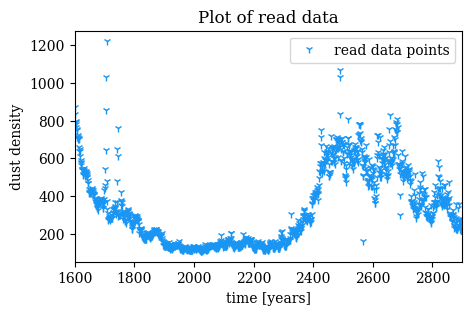

In [2]:
df = pd.read_csv('DustLog_forClass.dat',header=None,sep=" ")
x_array=df[0].values
y_array=df[1].values

x_min = x_array.min()
x_max = x_array.max()

y_min = y_array.min()
y_max = y_array.max()


fig,ax=plt.subplots(1)
ax.plot(x_array,y_array,marker=my_marker,color=my_cmap(0.2),linestyle="None",label="read data points")
ax.legend()
ax.set_xlabel("time [years]")
ax.set_xlim(x_min-0.5,x_max+0.5)
ax.set_ylabel("dust density")
ax.set_title("Plot of read data")

x_min, x_max, y_min, y_max
len(x_array)


## linear spline

In [3]:
xnew = np.linspace(x_min, x_max, num=len(x_array)*10, endpoint=True)
ynew = np.interp(xnew, x_array, y_array)


(1600.0, 2900.0)

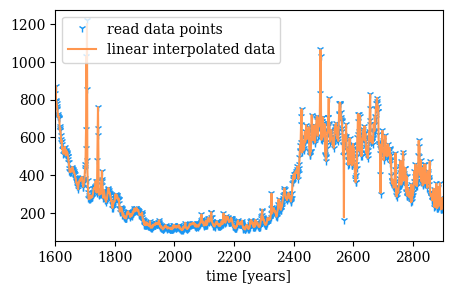

In [4]:
fig,ax=plt.subplots(1)
ax.plot(x_array,y_array,marker=my_marker,color=my_cmap(0.2),linestyle="None",label="read data points")
ax.plot(xnew,ynew,color=my_cmap(0.8),linestyle="-",label="linear interpolated data")
ax.legend()
ax.set_xlabel("time [years]")
ax.set_xlim(x_min-0.5,x_max+0.5)    

## cubic spline

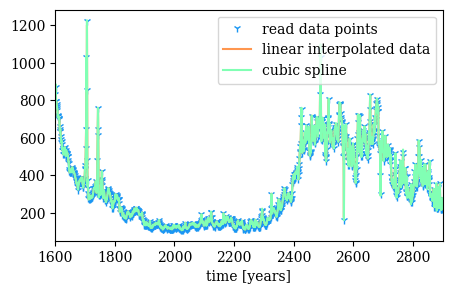

In [5]:
cub_spline=scipy.interpolate.interp1d(x_array, y_array, kind='cubic')
y_cubic=cub_spline(xnew)
ax.plot(xnew,y_cubic,color=my_cmap(0.5),linestyle="-",label="cubic spline")
ax.legend()
fig

## #2 making a pdf out of this

(np.float64(1e-05),
 np.float64(1.0),
 np.float64(1.327518),
 np.float64(174803.437423))

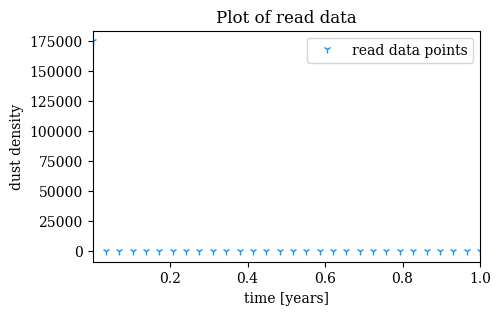

In [6]:
df = pd.read_csv('SplineCubic.txt',header=None,sep=" ")
x_array=df[0].values
y_array=df[1].values

x_min = x_array.min()
x_max = x_array.max()

y_min = y_array.min()
y_max = y_array.max()


fig,ax=plt.subplots(1)
ax.plot(x_array,y_array,marker=my_marker,color=my_cmap(0.2),linestyle="None",label="read data points")
ax.legend()
ax.set_xlabel("time [years]")
ax.set_xlim(x_min,x_max)
ax.set_ylabel("dust density")
ax.set_title("Plot of read data")

x_min, x_max, y_min, y_max
#len(x_array)


/tmp/ipykernel_26692/3337531689.py:12: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  int_lin_total=scipy.integrate.quad(lambda x: np.interp(x, xnew, ynew), x_min, x_max)


0.4934950370289175


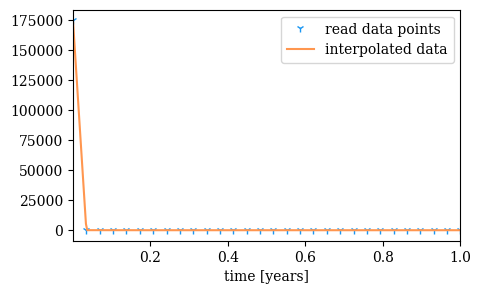

In [7]:
xnew = np.linspace(x_min, x_max, num=len(x_array)*10, endpoint=True)
ynew = np.interp(xnew, x_array, y_array)

fig,ax=plt.subplots(1)
ax.plot(x_array,y_array,marker=my_marker,color=my_cmap(0.2),linestyle="None",label="read data points")
ax.plot(xnew,ynew,color=my_cmap(0.8),linestyle="-",label="interpolated data")
ax.legend()
ax.set_xlabel("time [years]")
ax.set_xlim(x_min,x_max)

int_lin=scipy.integrate.quad(lambda x: np.interp(x, xnew, ynew), x_min, 0.01)
int_lin_total=scipy.integrate.quad(lambda x: np.interp(x, xnew, ynew), x_min, x_max)
print(int_lin[0]/int_lin_total[0])

0.6391152814163


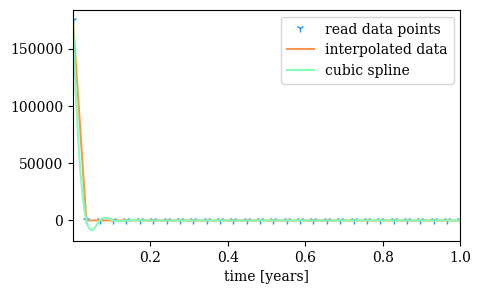

In [8]:
cub_spline=scipy.interpolate.interp1d(x_array, y_array, kind='cubic')
y_cubic=cub_spline(xnew)

ax.plot(xnew,y_cubic,color=my_cmap(0.5),linestyle="-",label="cubic spline")
ax.legend()

int_cub=scipy.integrate.quad(cub_spline, x_min, 0.01)
int_cub_total=scipy.integrate.quad(cub_spline, x_min, x_max)
print(int_cub[0]/int_cub_total[0])

fig

## #3 introducing smoothness

(np.float64(0.01), np.float64(100.0), np.float64(0.0), np.float64(0.991779))

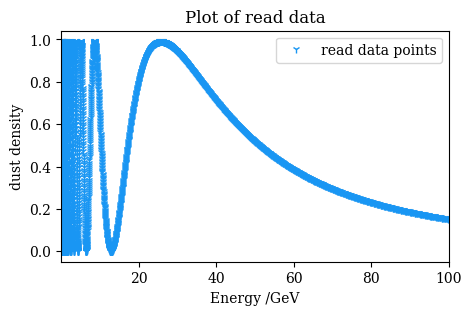

In [20]:
df = pd.read_csv('SplineOsc1.txt',header=None,sep=" ")
x_array=df[0].values
y_array=df[1].values

x_min = x_array.min()
x_max = x_array.max()

y_min = y_array.min()
y_max = y_array.max()

xnew = np.linspace(x_min, x_max, num=len(x_array)*10, endpoint=True)


fig,ax=plt.subplots(1)
ax.plot(x_array,y_array,marker=my_marker,color=my_cmap(0.2),linestyle="None",label="read data points")
ax.legend()
ax.set_xlabel("Energy /GeV")
ax.set_xlim(x_min,x_max)
ax.set_ylabel("dust density")
ax.set_title("Plot of read data")

x_min, x_max, y_min, y_max
#len(x_array)


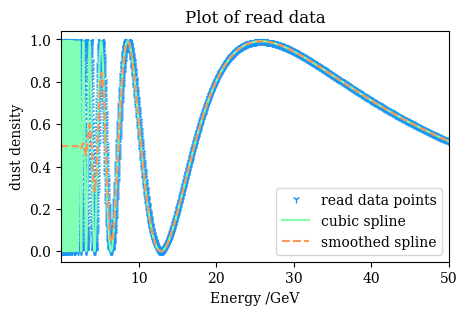

In [ ]:
cub_spline=scipy.interpolate.interp1d(x_array, y_array, kind='cubic')
y_cubic=cub_spline(xnew)


smoothy=scipy.interpolate.make_smoothing_spline(x_array, y_array, lam=0.5)

ax.plot(xnew,y_cubic,color=my_cmap(0.5),linestyle="-",label="cubic spline")
ax.plot(xnew, smoothy(xnew), color=my_cmap(0.9), linestyle="--", label="smoothed spline")
ax.set_xlim(x_min,x_max/2)
ax.legend()

fig